In [ ]:
# @title Default title text
import pandas as pd

# Dataset ko load karein
file_path = 'seasonal_agriculture_performance_dataset.xlsx'
df = pd.read_excel(file_path)

# Dataset ka shape aur pehli 5 rows dekhein
print("Dataset Shape (Rows, Columns):", df.shape)
df.head()

Dataset Shape (Rows, Columns): (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [ ]:
# Missing values check karein
print("Missing values before cleaning:")
print(df[["Rainfall_mm", "Soil_Moisture_pct", "Yield_Tonnes_Ha"]].isnull().sum())

# Null values ko Median se fill karein
df["Rainfall_mm"] = df["Rainfall_mm"].fillna(df["Rainfall_mm"].median())
df["Soil_Moisture_pct"] = df["Soil_Moisture_pct"].fillna(df["Soil_Moisture_pct"].median())
df["Yield_Tonnes_Ha"] = df["Yield_Tonnes_Ha"].fillna(df["Yield_Tonnes_Ha"].median())

# Verification: Clean hone ke baad missing values check
print("\nTotal missing values after cleaning:", df.isnull().sum().sum())

Missing values before cleaning:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

Total missing values after cleaning: 0


/tmp/ipykernel_4450/4143563187.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


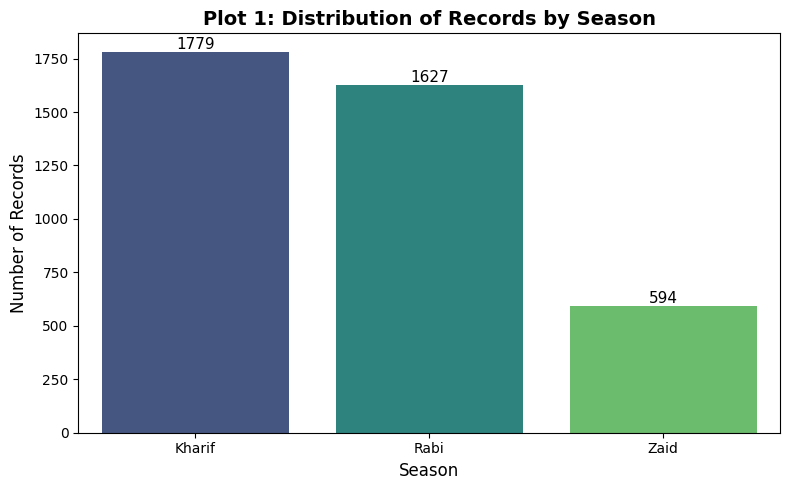

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot 1: Count of records by Season
plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=df,
    x="Season",
    palette="viridis",
    order=df["Season"].value_counts().index,
)
plt.title("Plot 1: Distribution of Records by Season", fontsize=14, fontweight="bold")
plt.xlabel("Season", fontsize=12)
plt.ylabel("Number of Records", fontsize=12)

# Value labels (counts) on top of bars
for p in ax.patches:
  ax.annotate(
      f"{int(p.get_height())}",
      (p.get_x() + p.get_width() / 2.0, p.get_height()),
      ha="center",
      va="bottom",
      fontsize=11,
  )

plt.tight_layout()
plt.savefig("plot1_season_distribution.png")
plt.show()

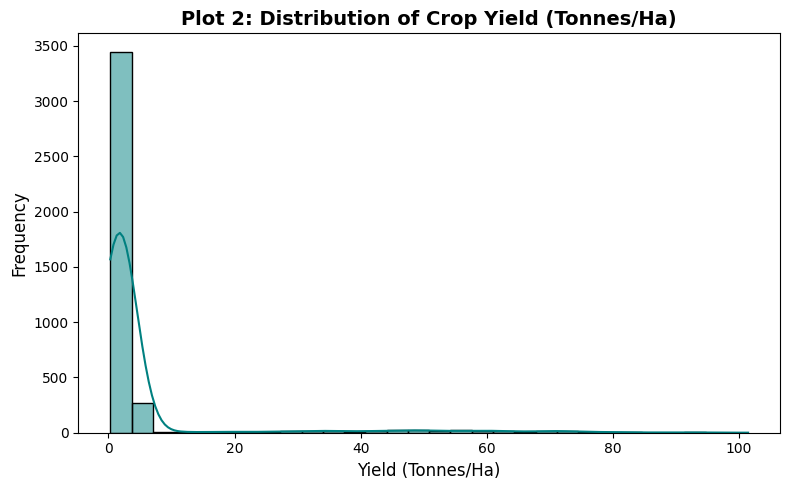

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot 2: Distribution of Crop Yield
plt.figure(figsize=(8, 5))
sns.histplot(df["Yield_Tonnes_Ha"], kde=True, color="teal", bins=30)
plt.title("Plot 2: Distribution of Crop Yield (Tonnes/Ha)", fontsize=14, fontweight="bold")
plt.xlabel("Yield (Tonnes/Ha)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.tight_layout()
plt.savefig("plot2_yield_distribution.png")
plt.show()

/tmp/ipykernel_4450/2922010777.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


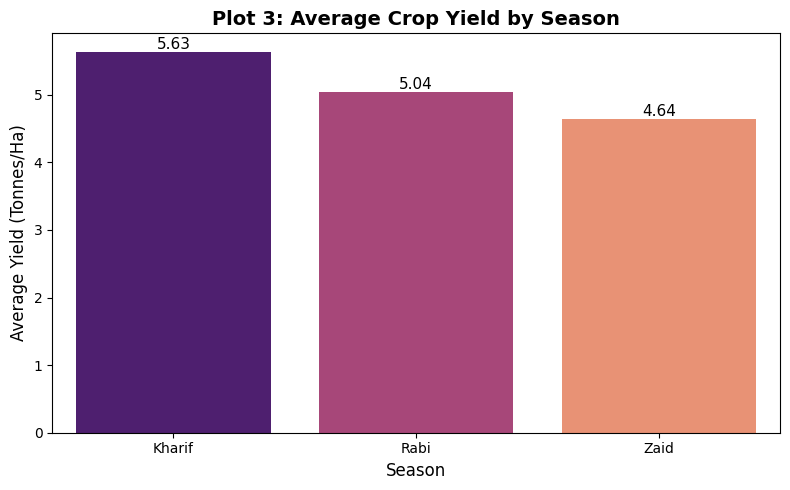

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot 3: Average Yield by Season
plt.figure(figsize=(8, 5))
avg_yield = (
    df.groupby("Season")["Yield_Tonnes_Ha"]
    .mean()
    .reset_index()
    .sort_values(by="Yield_Tonnes_Ha", ascending=False)
)

ax = sns.barplot(
    data=avg_yield, x="Season", y="Yield_Tonnes_Ha", palette="magma"
)
plt.title(
    "Plot 3: Average Crop Yield by Season", fontsize=14, fontweight="bold"
)
plt.xlabel("Season", fontsize=12)
plt.ylabel("Average Yield (Tonnes/Ha)", fontsize=12)

# Value labels on top of bars
for p in ax.patches:
  ax.annotate(
      f"{p.get_height():.2f}",
      (p.get_x() + p.get_width() / 2.0, p.get_height()),
      ha="center",
      va="bottom",
      fontsize=11,
  )

plt.tight_layout()
plt.savefig("plot3_avg_yield_by_season.png")
plt.show()

/tmp/ipykernel_4450/3774819207.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


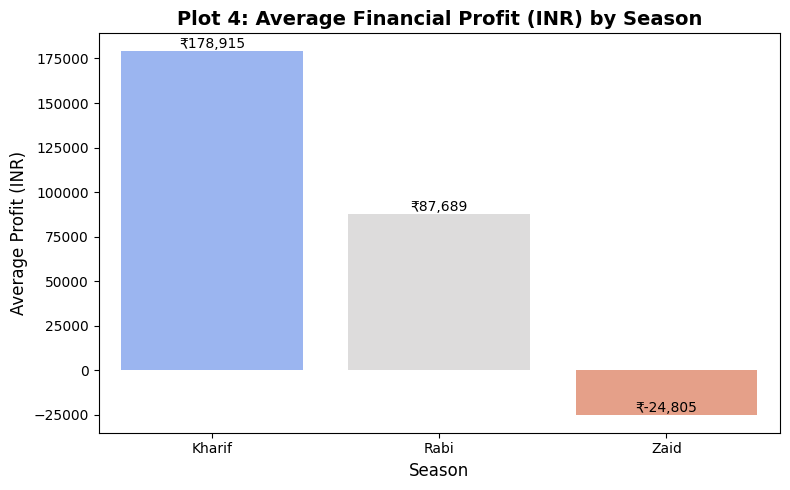

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot 4: Average Profit by Season
plt.figure(figsize=(8, 5))
avg_profit = df.groupby("Season")["Profit_INR"].mean().reset_index()

ax = sns.barplot(
    data=avg_profit, x="Season", y="Profit_INR", palette="coolwarm"
)
plt.title(
    "Plot 4: Average Financial Profit (INR) by Season",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Season", fontsize=12)
plt.ylabel("Average Profit (INR)", fontsize=12)

# Value labels on top of bars
for p in ax.patches:
  ax.annotate(
      f"₹{p.get_height():,.0f}",
      (p.get_x() + p.get_width() / 2.0, p.get_height()),
      ha="center",
      va="bottom",
      fontsize=10,
  )

plt.tight_layout()
plt.savefig("plot4_profit_by_season.png")
plt.show()

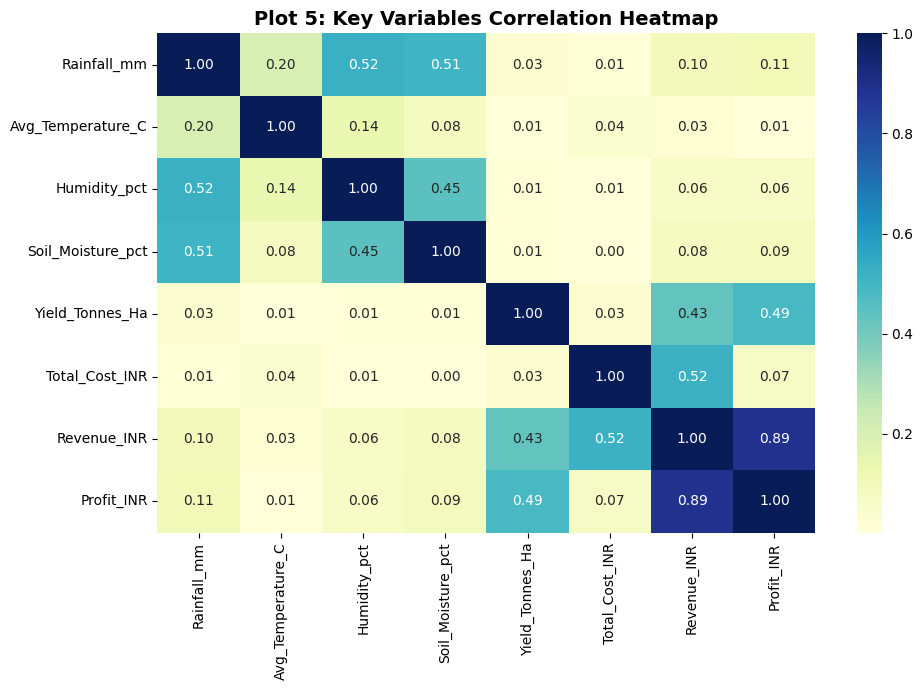

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot 5: Correlation Heatmap
plt.figure(figsize=(10, 7))
numeric_cols = [
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Soil_Moisture_pct",
    "Yield_Tonnes_Ha",
    "Total_Cost_INR",
    "Revenue_INR",
    "Profit_INR",
]

sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="YlGnBu", fmt=".2f")
plt.title(
    "Plot 5: Key Variables Correlation Heatmap", fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.savefig("plot5_correlation_heatmap.png")
plt.show()